# 02 RNN Basics

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Build a simple RNN (or LSTM) and process a **sequence** (e.g. text or time steps)
- Train it on a small sequence task (e.g. sentiment or next-step prediction) and see loss/accuracy
- Understand why we use an RNN instead of a plain feedforward NN for sequences

## 🔗 Where this fits

**Builds on:** Course 07 (AIAT 121) — Unit 4, lesson 02 "RNNs and LSTMs: Sequence Models Before Transformers" — you used an RNN on real text there; here we open up the recurrence itself.

---

## 🌍 Real life

**Where is this used?** RNNs are used for **text classification**, **time series**, **speech**, and **translation** when **order matters**.

**In this notebook we use** an **RNN** to process a **sequence** (e.g. padded word indices) and produce a single output (e.g. sentiment). We use an **RNN** (instead of a plain NN that sees all tokens at once) **because** **order matters**; the RNN processes step by step and keeps a **hidden state** that carries information forward.

**📌 Covers slide(s):** **17** — RNNs, vanishing/exploding gradients. *Do this notebook after that slide.*

---

**Before starting:** Run the imports cell below.


## Theory (short)

- **RNN:** At each time step t, it takes **input x_t** and **previous hidden state h_{t-1}**, and outputs **new hidden state h_t** (and optionally output y_t). So it maintains **memory** along the sequence.
- **Why sequences?** For text, time series, or any ordered data, the **order** of elements matters; an RNN processes them in order and passes information forward.
- **SimpleRNN vs LSTM:** SimpleRNN can suffer from vanishing gradients on long sequences; LSTM uses gates to control what to remember/forget. We use LSTM here for stability.
- **We use RNN** instead of a plain NN because a plain NN would treat the sequence as a flat bag of inputs and lose order.

## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy. We use a small text dataset (e.g. IMDB subset) or a synthetic sequence so the notebook runs in ~10 min.

**Dataset:** Real — IMDB (movie reviews, sentiment).

**Outputs:** Training/validation loss and accuracy (with axis labels), test accuracy, and a short "what you did" summary.

## Step 1: Imports and load a small sequence dataset

In [1]:
# WHAT: load the IMDB movie-review dataset as integer word IDs and pad every review to one length.
# WHY: RNNs need fixed-length numeric sequences - padding/truncating makes all reviews comparable.
import numpy as np
import matplotlib.pyplot as plt

# Guarded import: catch a broken TensorFlow install and print the exact repair command instead of a confusing crash.
try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

if HAS_TF:
    keras.utils.set_random_seed(0)   # same weights every run, so the curves below are reproducible
    # Keep the 2,000 most common words; pad or truncate each review to exactly maxlen tokens.
    (x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=2000)
    maxlen = 80
    x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen, padding="post", truncating="post")
    x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen, padding="post", truncating="post")
    # Small train/test subsets keep CPU training fast.
    x_train, y_train = x_train[:2000], y_train[:2000]
    x_test, y_test = x_test[:500], y_test[:500]
    print("Train:", x_train.shape, "Test:", x_test.shape)
else:
    print("Install TensorFlow: pip install tensorflow")

Train: (2000, 80) Test: (500, 80)


## Step 2: Build RNN model (we use LSTM instead of SimpleRNN for better gradient flow on sequences)

*Bridge note: here the LSTM is a **black-box drop-in** for SimpleRNN — same interface (sequence in, final state out), better gradient flow. Its internal gates are explained in the next notebook, `03_lstm_advanced`.*

In [2]:
# WHAT: build the classic text classifier - Embedding -> LSTM -> sigmoid.
# WHY: the Embedding turns word IDs into vectors; the LSTM reads them in order and remembers context.
if HAS_TF:
    model = keras.Sequential([
        keras.layers.Input(shape=(maxlen,)),   # declare the input length so summary() can count params
        keras.layers.Embedding(2000, 32),
        keras.layers.LSTM(32),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 80, 32)         │        64,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,353 (282.63 KB)

 Trainable params: 72,353 (282.63 KB)

 Non-trainable params: 0 (0.00 B)

## Step 3: Train (12 epochs — few enough to stay fast, enough for the curves to have a shape)

In [3]:
# WHAT: train for 8 epochs, one printed line per epoch.
# WHY: two epochs draw a two-point "curve" that cannot show anything. Twelve is still seconds
#      of CPU time, and it is enough for the train and validation curves to separate.
if HAS_TF:
    history = model.fit(x_train, y_train, validation_data=(x_test, y_test),
                        epochs=12, batch_size=64, verbose=2)

Epoch 1/12


32/32 - 1s - 23ms/step - accuracy: 0.5110 - loss: 0.6926 - val_accuracy: 0.4780 - val_loss: 0.6940


Epoch 2/12


32/32 - 0s - 8ms/step - accuracy: 0.6540 - loss: 0.6851 - val_accuracy: 0.5920 - val_loss: 0.6888


Epoch 3/12


...

32/32 - 0s - 8ms/step - accuracy: 0.9335 - loss: 0.1960 - val_accuracy: 0.7560 - val_loss: 0.6556


Epoch 11/12


32/32 - 0s - 8ms/step - accuracy: 0.9405 - loss: 0.1767 - val_accuracy: 0.7400 - val_loss: 0.7366


Epoch 12/12


32/32 - 0s - 8ms/step - accuracy: 0.9280 - loss: 0.1935 - val_accuracy: 0.7120 - val_loss: 0.8242


## Step 4: Plot loss and accuracy

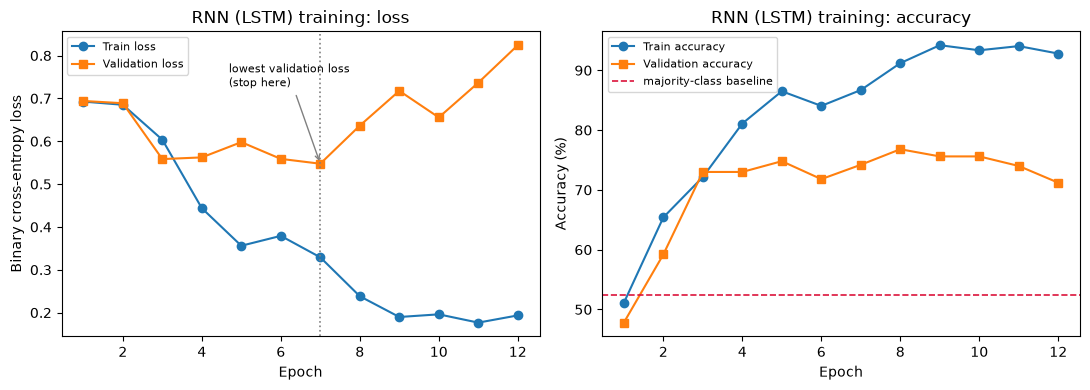

Test accuracy: 0.7120
Majority-class baseline: 0.5240


In [4]:
# WHAT: plot the LSTM's training curves and report test accuracy.
# WHY: the curves show whether the network is still improving or starting to overfit -
#      the gap between the train and validation lines IS the overfitting.
if HAS_TF:
    ep = np.arange(1, len(history.history["loss"]) + 1)
    best = int(np.argmin(history.history["val_loss"]))          # epoch with the lowest val loss
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

    ax1.plot(ep, history.history["loss"], "o-", label="Train loss")
    ax1.plot(ep, history.history["val_loss"], "s-", label="Validation loss")
    ax1.axvline(best + 1, color="grey", ls=":", lw=1.2)
    ax1.annotate("lowest validation loss\n(stop here)", xy=(best + 1, history.history["val_loss"][best]),
                 xytext=(0.35, 0.82), textcoords="axes fraction", fontsize=8,
                 arrowprops=dict(arrowstyle="->", color="grey"))
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Binary cross-entropy loss")
    ax1.set_title("RNN (LSTM) training: loss"); ax1.legend(fontsize=8)

    ax2.plot(ep, np.array(history.history["accuracy"]) * 100, "o-", label="Train accuracy")
    ax2.plot(ep, np.array(history.history["val_accuracy"]) * 100, "s-", label="Validation accuracy")
    ax2.axhline(max(y_test.mean(), 1 - y_test.mean()) * 100, color="crimson", ls="--", lw=1.2,
                label="majority-class baseline")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
    ax2.set_title("RNN (LSTM) training: accuracy"); ax2.legend(fontsize=8)
    plt.tight_layout(); plt.show()

    _, acc = model.evaluate(x_test, y_test, verbose=0)
    print("Test accuracy: %.4f" % acc)
    print("Majority-class baseline: %.4f" % max(y_test.mean(), 1 - y_test.mean()))

### 👁️ Read the figure

- **Left (loss):** the blue train-loss line falls all the way down to ~0.19. The orange validation line follows it down for about six epochs, bottoms out at the grey dotted line, and then **climbs back up** — by the last epoch it is *higher* than where it started. The two lines pulling apart after that dotted line is overfitting; it is not a metaphor, it is the picture. The dotted line is the epoch you would have stopped at.
- **Right (accuracy):** the same run, scored differently — and it turns **later**. Validation accuracy is still rising for a couple of epochs after the validation loss has already started to get worse. Both readings are correct: cross-entropy punishes being *confidently* wrong, accuracy only asks which side of 0.5 you landed on, and an overfitting network becomes over-confident before it becomes wrong. Watch loss for the stopping signal; quote accuracy to your audience.
- The red dashed line is the majority-class baseline — what you score by ignoring the review and always answering with the commoner label. A sentiment model is only interesting **above** that line, and this one clearly is.
- The seed is fixed, so re-running reproduces these curves. If you change the model and your picture stops matching this paragraph, trust the picture.

### What is the recurrence actually doing?

The curves say the model learns; they do not say *how*. The next cell opens the LSTM up: it re-runs the **same trained weights** over one real review and records the hidden state after every single word, plus the verdict the model would give if the review stopped there.

Picked review #235 (true label = positive, final P = 0.99) and review #274 (true label = negative, final P = 0.01).
Both are reviews the model gets RIGHT - 191 of 215 full-length positive and 125 of 236 negative ones qualify.

First 24 words of review #235: <start> normally i am a typical creepy <unk> girl but after watching this film on <unk> of course i'm having different <unk> and also ...

Review #274: the verdict was above 0.5 (i.e. WRONG) until word 51, then crossed below and stayed there.
   Read that as: 40-odd words of evidence were overturned by what came next.


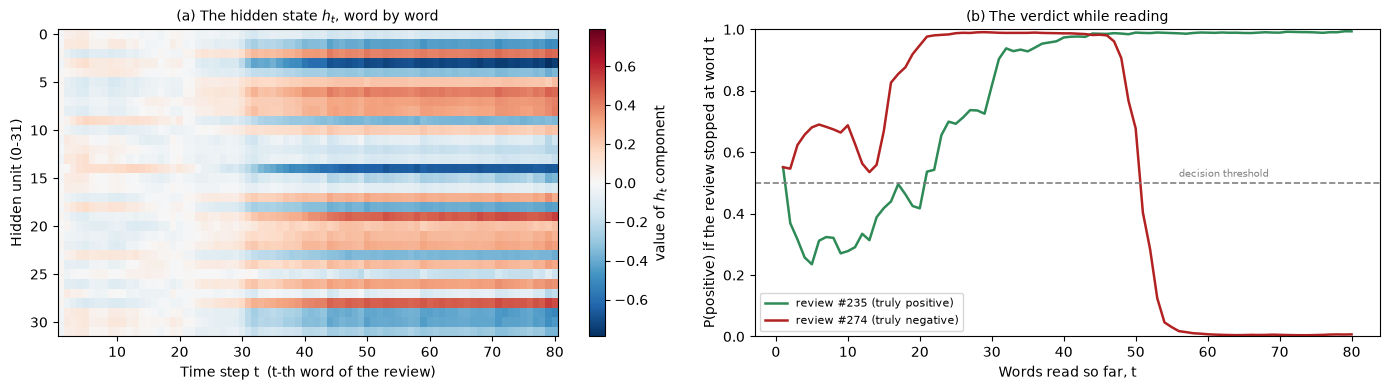

In [5]:
# WHAT: replay the TRAINED LSTM over one real review, keeping every intermediate hidden state
#       h_1..h_80 and the verdict the model would give after reading only t words.
# WHY:  "an RNN keeps a hidden state that carries information forward" is the whole lesson, and
#       so far it has only been a sentence. Here it is a picture: h_t changing word by word, and
#       the running probability sliding towards the answer as evidence arrives.
if HAS_TF:
    emb_layer, lstm_layer, dense_layer = model.layers[0], model.layers[1], model.layers[2]

    # A twin of the trained LSTM that RETURNS EVERY STEP instead of only the last one.
    # Same weights, copied across - nothing is retrained here.
    seq_lstm = keras.layers.LSTM(32, return_sequences=True)
    inp = keras.Input(shape=(maxlen,))
    h_seq = seq_lstm(emb_layer(inp))     # (batch, 80, 32) - the state after each word
    p_seq = dense_layer(h_seq)           # (batch, 80, 1)  - the verdict after each word
    probe = keras.Model(inp, [h_seq, p_seq])
    seq_lstm.set_weights(lstm_layer.get_weights())

    H, P = probe.predict(x_test, verbose=0)
    P = P[..., 0]

    # Use only reviews long enough to fill all 80 slots (no padding token anywhere), so every
    # step on the x-axis is a real word rather than filler.
    full = (x_test != 0).all(axis=1)
    pos_ok = np.where(full & (y_test == 1) & (P[:, -1] > 0.5))[0]
    neg_ok = np.where(full & (y_test == 0) & (P[:, -1] < 0.5))[0]
    i_pos = int(pos_ok[np.argmax(P[pos_ok, -1])])   # the positive review it is surest about
    i_neg = int(neg_ok[np.argmin(P[neg_ok, -1])])   # the negative review it is surest about
    print(f"Picked review #{i_pos} (true label = positive, final P = {P[i_pos, -1]:.2f}) "
          f"and review #{i_neg} (true label = negative, final P = {P[i_neg, -1]:.2f}).")
    print(f"Both are reviews the model gets RIGHT - {len(pos_ok)} of {int((full & (y_test==1)).sum())} "
          f"full-length positive and {len(neg_ok)} of {int((full & (y_test==0)).sum())} negative ones qualify.")

    # Turn the word IDs back into words so the review is readable, not a row of integers.
    widx = keras.datasets.imdb.get_word_index()
    inv = {v + 3: k for k, v in widx.items()}
    inv.update({0: "<pad>", 1: "<start>", 2: "<unk>", 3: "<unused>"})
    print("\nFirst 24 words of review #%d: " % i_pos
          + " ".join(inv.get(int(t), "?") for t in x_test[i_pos][:24]) + " ...")

    # Where did the negative review's verdict finally cross the 0.5 line for good?
    above = P[i_neg] >= 0.5
    crossings = np.where(above[:-1] & ~above[1:])[0]
    if len(crossings):
        flip = int(crossings[-1]) + 1
        print(f"\nReview #{i_neg}: the verdict was above 0.5 (i.e. WRONG) until word {flip + 1}, "
              f"then crossed below and stayed there.")
        print("   Read that as: 40-odd words of evidence were overturned by what came next.")

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 4))

    lim = float(np.abs(H[i_pos]).max())
    # extent puts word 1 at x=1 so this panel's x-axis lines up with panel (b)'s
    im = axL.imshow(H[i_pos].T, aspect="auto", cmap="RdBu_r", vmin=-lim, vmax=lim,
                    interpolation="nearest", extent=[0.5, maxlen + 0.5, 31.5, -0.5])
    axL.set_xlabel("Time step t  (t-th word of the review)")
    axL.set_ylabel("Hidden unit (0-31)")
    axL.set_title("(a) The hidden state $h_t$, word by word", fontsize=10)
    fig.colorbar(im, ax=axL, label="value of $h_t$ component")

    axR.plot(np.arange(1, maxlen + 1), P[i_pos], lw=1.8, color="seagreen",
             label=f"review #{i_pos} (truly positive)")
    axR.plot(np.arange(1, maxlen + 1), P[i_neg], lw=1.8, color="firebrick",
             label=f"review #{i_neg} (truly negative)")
    axR.axhline(0.5, color="grey", ls="--", lw=1.2)
    axR.text(56, 0.52, "decision threshold", fontsize=7.5, color="grey")
    axR.set_ylim(0, 1)
    axR.set_xlabel("Words read so far, t")
    axR.set_ylabel("P(positive) if the review stopped at word t")
    axR.set_title("(b) The verdict while reading", fontsize=10)
    axR.legend(fontsize=8, loc="lower left")
    plt.tight_layout(); plt.show()

### 👁️ Read the figure

- **(a)** Each column is one word of a real IMDB review; each row is one of the 32 numbers in the hidden state. Read it left to right: the colours in a column are **carried into** the next column and then nudged by the new word. The first ~20 columns are pale — the state is near zero, the model has read too little to commit. Between roughly word 22 and word 30 it **locks into a strong striped pattern**, some rows going deep red and others deep blue, and holds that pattern to the end. Some rows never move again once set; others change sign later. That is memory being written and overwritten. A bag-of-words model has no such picture, because it has no column-to-column arrow.
- **(b)** The same review reduced to the single number the classifier outputs, recomputed after each word, with a truly *negative* review for contrast. Two things are worth stopping on:
  1. The **green** line (truly positive) sits *below* the threshold for roughly words 4–19 — the model is leaning the wrong way early. Its climb over words ~19–35 is the same event that panel (a) shows locking in, and by about word 45 it is pinned near 1.0.
  2. The **red** line (truly negative) is worse: from about word 18 to word 46 the model is **confidently wrong**, sitting near 0.99. Then it collapses through the threshold and stays near 0 for the rest of the review. The cell prints the exact word position of that final crossing. Forty words of accumulated evidence were overturned by what came next — **which a bag-of-words model cannot do, because it has no "next".**
- **This trajectory only exists because the state carries forward.** A model that saw all 80 words at once would give you one point here, not a curve.
- Honest caveat: both reviews are ones the model ends up classifying **correctly**, chosen on purpose so the mechanism is legible. As the red line shows, "ends up right" and "was right all along" are very different things.

## 🌍 Real-World Worked Example — Stock Trend Prediction (and an Honesty Check)

**Industry context:** Hedge funds and trading platforms really do run LSTMs on price
sequences — and most claimed "prediction accuracy" evaporates once it is compared
against the right baseline.

We train an LSTM to predict whether a **synthetic stock price** goes up or down the
next day. The data is a **random walk with upward drift**: each day's move is drawn
independently of the past, so the *only* learnable signal is the drift itself. That
makes the honest benchmark the **base rate** (always predict the majority direction),
not the 50% coin flip that "stock prediction" demos usually quote. Watch how the
comparison changes the story.

LSTM direction accuracy:          59.2%
Always-predict-majority baseline: 59.2%  (test set is 59.2% 'up' days)
LSTM edge over the honest baseline: +0.0 points
The trained LSTM answers 'up' on 100% of test days.

By construction, each day's move is INDEPENDENT of the past 20 days,
so no model can consistently beat the base rate on this data - any gap
either way is test-set noise (1 standard error is +/-3.5 points at n=196).
Lesson: always compare a 'market predictor' to the base rate, not to 50%.


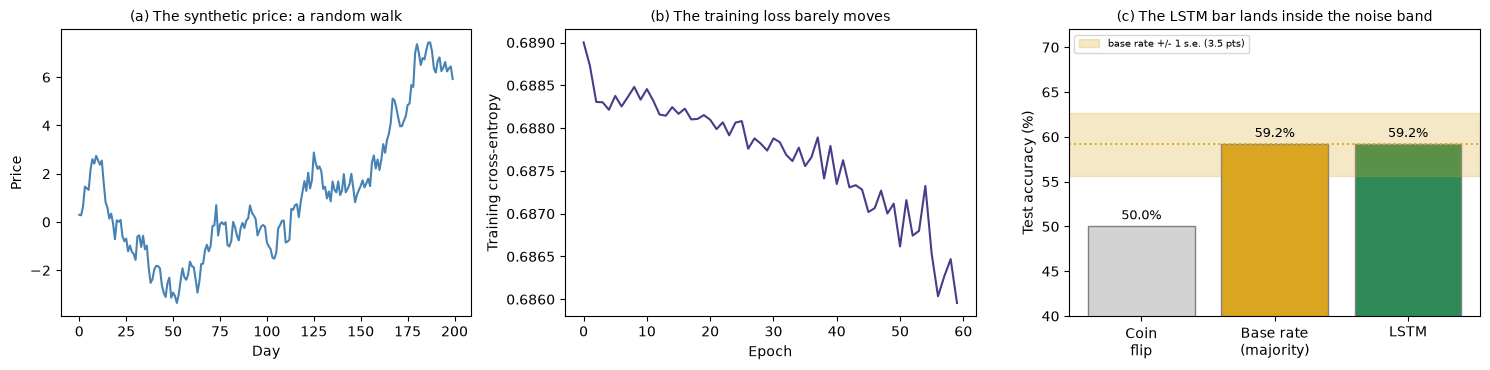

In [6]:
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, matplotlib.pyplot as plt

# ── Generate a stock-like price series: a RANDOM WALK with drift ─────────
# Each daily step is independent N(+0.05, 0.5) — the past 20 days carry NO
# information about tomorrow beyond the constant drift.
np.random.seed(42)
torch.manual_seed(0)
n = 1000
price = np.cumsum(np.random.randn(n) * 0.5 + 0.05).astype(np.float32)

# Create sequences: use 20 days to predict direction on day 21
SEQ_LEN = 20
X_list, y_list = [], []
for i in range(len(price) - SEQ_LEN - 1):
    X_list.append(price[i:i+SEQ_LEN])
    y_list.append(1 if price[i+SEQ_LEN] > price[i+SEQ_LEN-1] else 0)

X_arr = np.array(X_list); y_arr = np.array(y_list)
# Normalise each sequence
X_arr = (X_arr - X_arr.mean(1,keepdims=True)) / (X_arr.std(1,keepdims=True)+1e-8)

split = int(0.8*len(X_arr))
Xtr = torch.tensor(X_arr[:split]).unsqueeze(-1)  # (N, 20, 1)
Ytr = torch.tensor(y_arr[:split], dtype=torch.long)
Xte = torch.tensor(X_arr[split:]).unsqueeze(-1)
Yte = torch.tensor(y_arr[split:], dtype=torch.long)

# ── LSTM Model ──────────────────────────────────────────────────────
class TrendLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 32, batch_first=True, num_layers=2, dropout=0.2)
        self.fc   = nn.Linear(32, 2)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])   # last time step

model   = TrendLSTM()
opt     = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
losses  = []

for epoch in range(60):
    model.train()
    loss = loss_fn(model(Xtr), Ytr)
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())

# ── Honest evaluation: compare against the base rate, not against 50% ─────
model.eval()
with torch.no_grad():
    pred = model(Xte).argmax(1)
acc = (pred == Yte).float().mean().item()
frac_up = pred.float().mean().item()   # what fraction of test days does it call 'up'?
p_up = Yte.float().mean().item()
base = max(p_up, 1.0 - p_up)   # always predict the majority direction

se = 100.0 * np.sqrt(base * (1 - base) / len(Yte))   # 1 standard error on a test set this small
print(f"LSTM direction accuracy:          {acc*100:.1f}%")
print(f"Always-predict-majority baseline: {base*100:.1f}%  (test set is {p_up*100:.1f}% 'up' days)")
print(f"LSTM edge over the honest baseline: {(acc-base)*100:+.1f} points")
print(f"The trained LSTM answers 'up' on {frac_up*100:.0f}% of test days.")
print()
print("By construction, each day's move is INDEPENDENT of the past 20 days,")
print(f"so no model can consistently beat the base rate on this data - any gap")
print(f"either way is test-set noise (1 standard error is +/-{se:.1f} points at n={len(Yte)}).")
print("Lesson: always compare a 'market predictor' to the base rate, not to 50%.")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
axes[0].plot(price[:200], color="steelblue")
axes[0].set_title("(a) The synthetic price: a random walk", fontsize=10)
axes[0].set_xlabel("Day"); axes[0].set_ylabel("Price")

axes[1].plot(losses, color="darkslateblue")
axes[1].set_title("(b) The training loss barely moves", fontsize=10)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Training cross-entropy")

labels = ["Coin\nflip", "Base rate\n(majority)", "LSTM"]
vals = [50.0, base * 100, acc * 100]
bars = axes[2].bar(labels, vals, color=["lightgrey", "goldenrod", "seagreen"], edgecolor="grey")
axes[2].bar_label(bars, fmt="%.1f%%", fontsize=9, padding=3)
# The band is what "no difference" looks like once test-set noise is admitted.
axes[2].axhspan(base * 100 - se, base * 100 + se, color="goldenrod", alpha=0.25,
                label=f"base rate +/- 1 s.e. ({se:.1f} pts)")
axes[2].axhline(base * 100, color="goldenrod", ls=":", lw=1.4)
axes[2].set_ylim(40, 72)
axes[2].set_ylabel("Test accuracy (%)")
axes[2].set_title("(c) The LSTM bar lands inside the noise band", fontsize=10)
axes[2].legend(fontsize=7.5, loc="upper left")
plt.tight_layout(); plt.show()

### 👁️ Read the figure

- **(a)** The price wanders. It has an upward tilt (the drift we built in) and no repeating structure, because every daily step was drawn independently of the past.
- **(b)** The loss does fall — so the optimiser is working and the code is not broken — but **read the y-axis**: it spans about 0.003 of cross-entropy in 60 epochs. A falling loss curve proves the plumbing works. It never proves the result is useful, and here there is nothing to learn.
- **(c)** The honest scoreboard. Against a coin flip (grey) the LSTM looks like a winner. Against the base rate — the golden line, i.e. "always say up" — **the green bar tops out at exactly the same height as the golden one, inside the shaded band** that marks ordinary test-set noise on a test set this small. The printed line above says why they match to the decimal: the network answers "up" on essentially every test day. It has rediscovered the base-rate rule and nothing else, which on structureless data is the only correct outcome. Any tutorial that reports the grey comparison instead of the golden one is selling you the noise.

## 🧩 Mini-exercise

**Try it (choose one):** Change the number of LSTM units (e.g. 32 → 64) and retrain for 1 epoch. Does loss go down faster? Or reduce the embedding dimension and see how it affects accuracy.

---

## ✅ Summary

**What you did:** Built an RNN (LSTM) for sequence classification (IMDB sentiment), trained it for 2 epochs, and plotted loss/accuracy.

**In real life you'd also:** Use longer sequences, more data, and tune embedding size and LSTM units.

**The main idea:** RNNs process sequences step by step and keep a hidden state; we use them (instead of a plain NN) when **order matters**.

**Next:** `03_lstm_advanced` goes deeper into LSTM/GRU; `04_transformer_attention` introduces attention and transformers.

## 🔭 State of the field (2026)

Production sequence models are transformers. If you are shipping text classification or generation in 2026 you start from a pretrained transformer, not from the recurrent layer you just trained — the reason is that recurrence forces the sequence through one step at a time, so it cannot use a modern accelerator's parallelism during training.

**But the recurrent line is not closed.** Two 2024 results reopened it. xLSTM (arXiv 2405.04517) added exponential gating and a matrix memory and scaled the LSTM to billions of parameters, competitive with transformers on language modelling. Feng et al., *Were RNNs All We Needed?* (arXiv 2410.01201), removed the gates' dependence on the previous hidden state and obtained minimal LSTM/GRU variants that are fully parallelisable during training with fewer parameters. Both papers are edits to the recurrence relation on this page; you cannot read either one without knowing what h_t is.

**And the mechanism is the point.** An RNN is the shortest honest answer to "what is a model with state?", and state is what a transformer buys back at inference time with its key/value cache. This lesson is also what the official plan examines. Learn the recurrence here; you will meet it again wearing different clothes.


## 📚 References

1. Elman, J. L. (1990). *Finding Structure in Time*. Cognitive Science 14(2), 179-211. https://doi.org/10.1207/s15516709cog1402_1
2. Hochreiter, S. & Schmidhuber, J. (1997). *Long Short-Term Memory*. Neural Computation 9(8), 1735-1780. https://doi.org/10.1162/neco.1997.9.8.1735
3. Cho, K. et al. (2014). *Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation* (GRU). EMNLP. https://arxiv.org/abs/1406.1078

**Recent work (2024–2026)**

4. Beck, M. et al. (2024). *xLSTM: Extended Long Short-Term Memory*. arXiv. https://arxiv.org/abs/2405.04517 — recurrence did not die in 2024: exponential gating plus a matrix memory scaled the LSTM to billions of parameters, competitive with transformers on language modelling.
5. Feng, L., Tung, F., Ahmed, M. O., Bengio, Y. & Hajimirsadeghi, H. (2024). *Were RNNs All We Needed?* arXiv. https://arxiv.org/abs/2410.01201 — minimal LSTM/GRU variants with the hidden-state dependence removed from the gates, which makes them fully parallelisable during training — the constraint that pushed the field to transformers in the first place.
